# Notebook 4: GraphFrames for Financial Transaction Network Analysis

## Graph Analytics with PySpark and GraphFrames

In this notebook, graph analytics techniques are applied to a financial transaction dataset using PySpark and GraphFrames.

The dataset represents financial transactions between accounts, where accounts are modelled as vertices and transactions as edges in a directed graph. By representing the full transaction network as a graph, it becomes possible to identify structural patterns, highly connected accounts, suspicious clusters, and indirect relationships across the entire payment system.

# 1. Environment Setup

The following cells configure the PySpark and GraphFrames environment used throughout this notebook.

In [1]:
!pip install "pyspark==3.5.0"

In [2]:
!sudo apt-get update
!sudo apt-get install -y openjdk-17-jdk-headless

!java -version

Hit:1 https://download.docker.com/linux/ubuntu noble InRelease
Hit:2 https://packages.cloud.google.com/apt cloud-sdk InRelease
Get:3 https://cli.github.com/packages stable InRelease [3917 B]
Hit:4 https://us-east-1.ec2.archive.ubuntu.com/ubuntu noble InRelease          
Hit:5 https://us-east-1.ec2.archive.ubuntu.com/ubuntu noble-updates InRelease  
Hit:6 https://us-east-1.ec2.archive.ubuntu.com/ubuntu noble-backports InRelease
Hit:7 https://cloud.archive.ubuntu.com/ubuntu noble InRelease                  
Hit:8 https://cloud.archive.ubuntu.com/ubuntu noble-updates InRelease          
Hit:9 https://security.ubuntu.com/ubuntu noble-security InRelease   
Hit:10 https://cloud.archive.ubuntu.com/ubuntu noble-backports InRelease
Hit:11 http://deb.wakemeops.com/wakemeops stable InRelease          
Hit:12 https://cloud.archive.ubuntu.com/ubuntu noble-security InRelease
Hit:13 https://archive.ubuntu.com/ubuntu noble InRelease
Hit:14 https://archive.ubuntu.com/ubuntu noble-updates InRelease
Hit:

In [3]:
%pip install graphframes-py==0.10.0

Note: you may need to restart the kernel to use updated packages.


In [4]:
# Set JAVA_HOME to Java 17
import os

os.environ["JAVA_HOME"] = "/usr/lib/jvm/java-17-openjdk-amd64"

from pyspark.sql import SparkSession

spark = SparkSession.builder \
    .appName("GraphFramesFraudAnalysis") \
    .config("spark.jars.packages", "graphframes:graphframes:0.8.4-spark3.5-s_2.12") \
    .config("spark.driver.memory", "4g") \
    .config("spark.executor.memory", "4g") \
    .config("spark.driver.maxResultSize", "2g") \
    .getOrCreate()

:: loading settings :: url = jar:file:/system/conda/miniconda3/envs/cloudspace/lib/python3.12/site-packages/pyspark/jars/ivy-2.5.1.jar!/org/apache/ivy/core/settings/ivysettings.xml


Ivy Default Cache set to: /home/zeus/.ivy2/cache
The jars for the packages stored in: /home/zeus/.ivy2/jars
graphframes#graphframes added as a dependency
:: resolving dependencies :: org.apache.spark#spark-submit-parent-d49a0eae-1c87-49ab-8904-5e859940621c;1.0
	confs: [default]
	found graphframes#graphframes;0.8.4-spark3.5-s_2.12 in spark-packages
	found org.slf4j#slf4j-api;1.7.16 in central
:: resolution report :: resolve 173ms :: artifacts dl 7ms
	:: modules in use:
	graphframes#graphframes;0.8.4-spark3.5-s_2.12 from spark-packages in [default]
	org.slf4j#slf4j-api;1.7.16 from central in [default]
	---------------------------------------------------------------------
	|                  |            modules            ||   artifacts   |
	|       conf       | number| search|dwnlded|evicted|| number|dwnlded|
	---------------------------------------------------------------------
	|      default     |   2   |   0   |   0   |   0   ||   2   |   0   |
	-------------------------------------

In [5]:
from graphframes import *
from graphframes import GraphFrame

from pyspark.sql.types import *
from pyspark.sql import Row
from pyspark.sql.functions import *

from pyspark.sql import functions as F
from pyspark.sql.window import Window

sc = spark.sparkContext

# GraphFrames connected components requires checkpointing
sc.setCheckpointDir("/tmp/graphframes-checkpoints")

spark.conf.set("spark.sql.shuffle.partitions", "16")

print("Environment ready.")

Environment ready.


# 2. Financial Transaction Network Context

The dataset used in this notebook is the PaySim synthetic dataset, which simulates mobile money transactions over a 30-day period. Each record represents a financial transaction between two accounts and includes the following attributes:

- **nameOrig**: account that initiated the transaction
- **nameDest**: account that received the transaction
- **type**: transaction type (CASH-IN, CASH-OUT, DEBIT, PAYMENT, TRANSFER)
- **amount**: transaction amount in local currency
- **isFraud**: label indicating whether the transaction was fraudulent

To perform graph analytics, the transactional data is transformed into a graph structure:

- **Accounts → vertices** (nodes)
- **Transactions → edges** (directed, from sender to receiver)

### Graph Representation

| Graph Element | Financial Meaning |
|---|---|
| Vertex | Bank account |
| Edge | Financial transaction |
| Directed edge | Transfer from one account to another |
| Degree | Number of connections of an account |
| Connected Component | Group of related accounts |
| PageRank | Importance/influence of an account in the network |

In [5]:
from pyspark.sql import SparkSession

spark = SparkSession.builder \
    .appName("GraphFrames Analysis") \
    .getOrCreate()

Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
26/05/19 23:22:18 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable


In [6]:
df_paysim_clean = spark.read.parquet(
    "data/clean/paysim_clean.parquet"
)

df_paysim_clean.show()

+----+-------+---------+-----------+-------------+--------------+-----------+--------------+--------------+-------+--------------+
|step|   type|   amount|   nameOrig|oldbalanceOrg|newbalanceOrig|   nameDest|oldbalanceDest|newbalanceDest|isFraud|isFlaggedFraud|
+----+-------+---------+-----------+-------------+--------------+-----------+--------------+--------------+-------+--------------+
| 156|CASH_IN| 27287.59|C1634109320|   8673566.52|    8700854.11|C1542157370|     558897.81|     531610.22|  false|         false|
| 156|CASH_IN|165163.88|C1684617623|   8700854.11|    8866017.99|C1163394047|     272799.53|     107635.65|  false|         false|
| 156|CASH_IN| 79644.29| C577027691|   8866017.99|    8945662.28|C1036272123|     226798.95|     147154.66|  false|         false|
| 156|CASH_IN|304420.49| C276094466|   8945662.28|    9250082.78|C1040552729|     1160376.3|      855955.8|  false|         false|
| 156|CASH_IN|142280.37|C1174098243|   9250082.78|    9392363.15| C508275836|     6

# 3. Data to Graph Structure

To analyse transactional relationships between accounts, we convert the PaySim dataset into a graph structure using GraphFrames.

In this representation:

- Each account is represented as a vertex (node)
- Each transaction is represented as an edge
- The transaction direction goes from the origin account (`nameOrig`) to the destination account (`nameDest`)

## 3.1 Vertex Construction

We construct the set of vertices by collecting all unique account identifiers appearing in the dataset, both as senders and receivers.

Each vertex represents one unique account in the transaction network.

In [8]:
vertices = (
    df_paysim_clean
    .selectExpr("nameOrig as id")
    .union(
        df_paysim_clean.selectExpr("nameDest as id")
    )
    .distinct()
)

## 3.2 Edge Construction

Next, we construct the edges representing the transactional flows between accounts.

Each edge contains:
- source account (`src`)
- destination account (`dst`)
- transaction amount
- transaction type
- fraud label

In [9]:
edges = df_paysim_clean.selectExpr(
    "nameOrig as src",
    "nameDest as dst",
    "amount",
    "type",
    "isFraud"
)

## 3.3 GraphFrame Creation

Using the vertices and edges DataFrames, we instantiate a GraphFrame object that will support graph-based analysis over the transactional network.

In [10]:
g = GraphFrame(vertices, edges)

print("Graph successfully created.")

Graph successfully created.


# 4. Graph Exploration

After constructing the transaction network graph, we perform an initial exploration of the network structure.

This stage focuses on:
- measuring the size of the graph
- inspecting vertices and edges
- analysing account connectivity through degree metrics

These exploratory steps provide an overview of the network before applying more advanced graph analytics algorithms.

## 4.1 Graph Size

We first evaluate the scale of the full transaction graph by counting the total number of unique accounts (vertices) and transaction flows (edges).

In [11]:
num_vertices = vertices.count()
num_edges = edges.count()

print(f"Total vertices (accounts): {num_vertices:,}")
print(f"Total edges (transactions): {num_edges:,}")

Total vertices (accounts): 9,073,900
Total edges (transactions): 6,362,620


The full transaction graph contains **9,073,900 unique accounts** (vertices) connected through **6,362,620 transaction flows** (edges), representing one month of simulated mobile money activity.

## 4.2 Inspect Vertices and Edges

In [12]:
print("Vertices:")
vertices.show(10, truncate=False)

print("Edges:")
edges.show(10, truncate=False)

Vertices:


+-----------+
|id         |
+-----------+
|C1634109320|
|C1070264759|
|C643298678 |
|C615628551 |
|C642340754 |
|C1157064131|
|C263860433 |
|C1476206005|
|C592608401 |
|C696324938 |
+-----------+
only showing top 10 rows

Edges:
+-----------+-----------+---------+-------+-------+
|src        |dst        |amount   |type   |isFraud|
+-----------+-----------+---------+-------+-------+
|C1634109320|C1542157370|27287.59 |CASH_IN|false  |
|C1684617623|C1163394047|165163.88|CASH_IN|false  |
|C577027691 |C1036272123|79644.29 |CASH_IN|false  |
|C276094466 |C1040552729|304420.49|CASH_IN|false  |
|C1174098243|C508275836 |142280.37|CASH_IN|false  |
|C1760787946|C854984866 |126660.78|CASH_IN|false  |
|C1868763513|C2136056548|90602.74 |CASH_IN|false  |
|C1506887257|C1065774928|187781.09|CASH_IN|false  |
|C1178559849|C254242855 |9786.35  |CASH_IN|false  |
|C894458985 |C1699937332|171696.71|CASH_IN|false  |
+-----------+-----------+---------+-------+-------+
only showing top 10 rows



The vertex DataFrame contains unique account identifiers prefixed with `C` (customers) or `M` (merchants). The majority are customers.

## 4.3 Degree Analysis

Degree analysis measures the connectivity of each account within the full transaction network.

In graph terminology:
- **in-degree**:number of incoming transactions received by an account
- **out-degree**: number of outgoing transactions initiated by an account
- **total degree**: total number of connections associated with an account

Accounts with unusually high degree values may represent central financial entities (such as merchants, aggregators, or potentially suspicious hubs) that participate in a disproportionately large number of transactions.

In [34]:
in_degrees = g.inDegrees.orderBy("inDegree", ascending=False)

print("Top accounts by incoming transactions:")
in_degrees.show(10, truncate=False)

Top accounts by incoming transactions:


+-----------+--------+
|id         |inDegree|
+-----------+--------+
|C1286084959|113     |
|C985934102 |109     |
|C665576141 |105     |
|C2083562754|102     |
|C1590550415|101     |
|C248609774 |101     |
|C451111351 |99      |
|C1789550256|99      |
|C1360767589|98      |
|C1023714065|97      |
+-----------+--------+
only showing top 10 rows



In [35]:
out_degrees = g.outDegrees.orderBy("outDegree", ascending=False)

print("Top accounts by outgoing transactions:")
out_degrees.show(10, truncate=False)

Top accounts by outgoing transactions:


+-----------+---------+
|id         |outDegree|
+-----------+---------+
|C1677795071|3        |
|C1902386530|3        |
|C1784010646|3        |
|C1832548028|3        |
|C400299098 |3        |
|C1065307291|3        |
|C363736674 |3        |
|C1530544995|3        |
|C1976208114|3        |
|C2098525306|3        |
+-----------+---------+
only showing top 10 rows



In [15]:
degrees = g.degrees.orderBy("degree", ascending=False)

print("Top most connected accounts:")
degrees.show(10, truncate=False)

Top most connected accounts:


+-----------+------+
|id         |degree|
+-----------+------+
|C1286084959|113   |
|C985934102 |109   |
|C665576141 |105   |
|C2083562754|102   |
|C1590550415|101   |
|C248609774 |101   |
|C451111351 |99    |
|C1789550256|99    |
|C1360767589|98    |
|C1023714065|97    |
+-----------+------+
only showing top 10 rows



The degree analysis reveals a highly asymmetric network structure. On the **in-degree** side, the top accounts receive up to 113 incoming transactions. On the **out-degree** side, the maximum observed is only 3, confirming that individual accounts rarely initiate more than a handful of outgoing transfers.

Total degree values closely mirror in-degree, indicating that high connectivity in this network is driven primarily by receiving activity rather than sending, consistent with a hub-and-spoke payment topology *(image below)*.

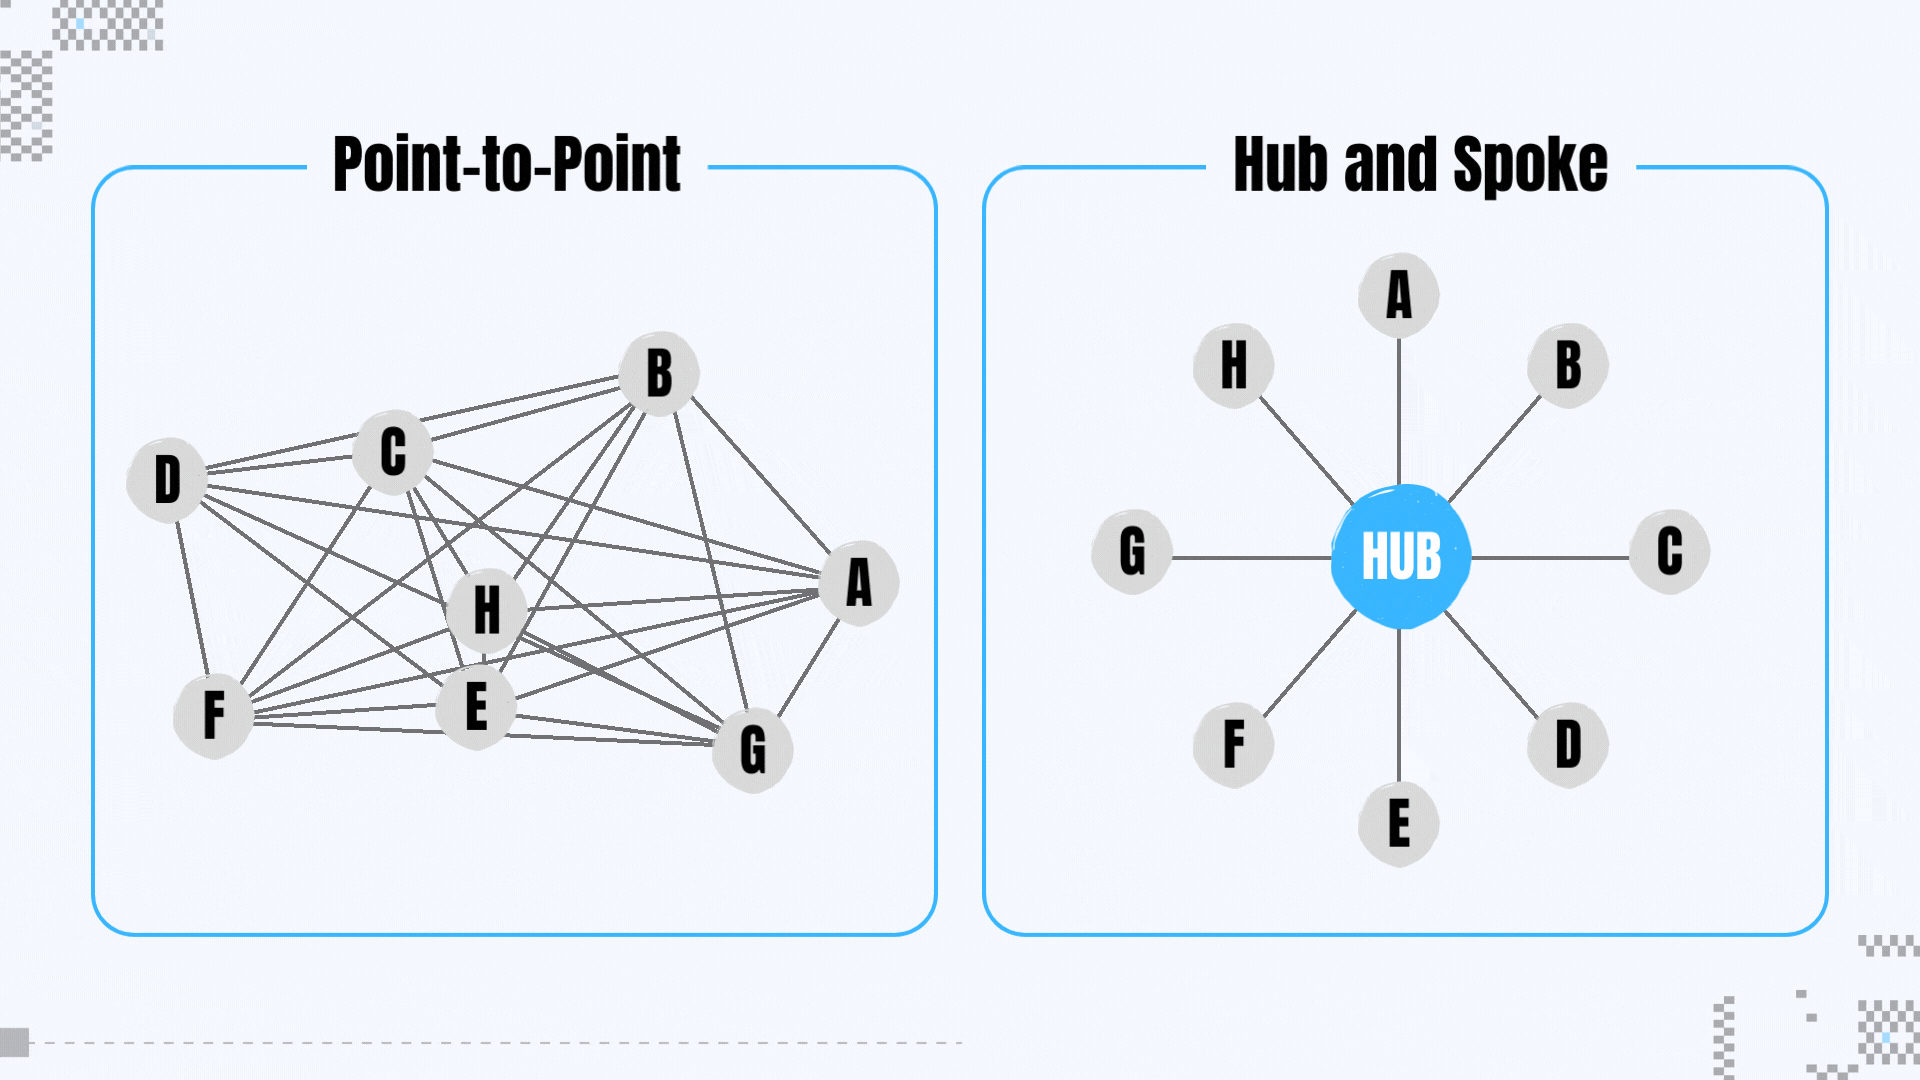

In [3]:
from IPython.display import Image, display

display(Image(filename="../payment_topology.gif", width=400))

# 4.4 Degree Distribution

To better understand the structural characteristics of the fraud network, we analyse the degree distribution of the graph.

This analysis helps identify whether the network contains highly connected hubs or whether most accounts participate in only a few fraudulent transactions.

In [16]:
degree_distribution = (
    degrees
    .groupBy("degree")
    .count()
    .orderBy("degree")
)

degree_distribution.show()

+------+-------+
|degree|  count|
+------+-------+
|     1|8604623|
|     2|  86428|
|     3|  57345|
|     4|  45157|
|     5|  36862|
|     6|  30427|
|     7|  25816|
|     8|  21920|
|     9|  18643|
|    10|  16341|
|    11|  14344|
|    12|  12386|
|    13|  10985|
|    14|   9708|
|    15|   8672|
|    16|   7706|
|    17|   6705|
|    18|   6109|
|    19|   5461|
|    20|   4914|
+------+-------+
only showing top 20 rows



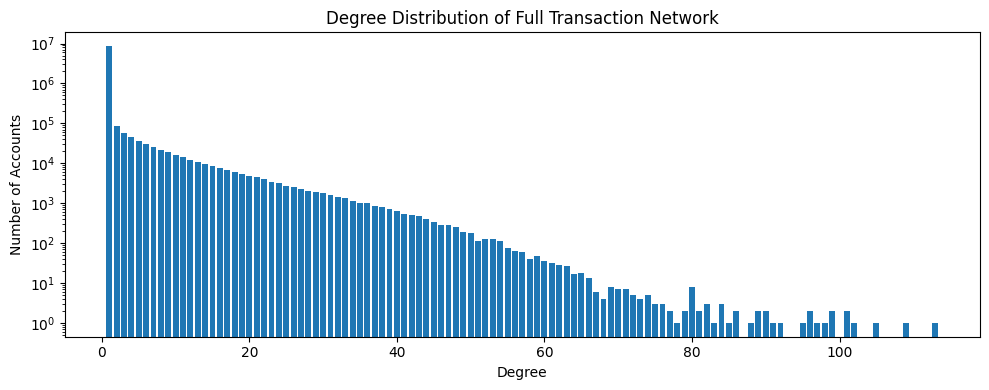

In [17]:
import matplotlib.pyplot as plt

degree_pd = degree_distribution.toPandas()

plt.figure(figsize=(10, 4))
plt.bar(degree_pd["degree"], degree_pd["count"])
plt.xlabel("Degree")
plt.ylabel("Number of Accounts")
plt.title("Degree Distribution of Full Transaction Network")
plt.yscale("log")  # log scale for better readability given skewed distribution
plt.tight_layout()
plt.show()

The degree distribution confirms a strongly right-skewed, power-law-like pattern typical of real-world financial networks: **8,604,623 accounts** (the vast majority) have a degree of exactly 1,  meaning they participate in only a single transaction. The number of accounts drops sharply as degree increases, with only a small number of highly connected hub accounts reaching degrees above 50.

This distribution has important implications for fraud detection: fraudulent accounts, if structurally distinct, should stand out as anomalies against this baseline of low-connectivity legitimate accounts.

# 5. Motif Finding

Motif finding is used to identify recurring structural transaction patterns within the fraud network.

Unlike degree analysis, which focuses on node connectivity, motif analysis searches for specific transactional structures that may reveal suspicious behaviours such as transaction chains, repeated transfers, or circular flows.

## 5.1 Simple Transaction Pattern

We first identify the simplest motif: a direct transaction between two accounts.

This motif captures all direct account-to-account transfers in the network. We filter for high-value transactions to surface the most significant flows.

In [18]:
simple_motif = g.find("(a)-[e]->(b)")

# Filter for high-value transactions to surface significant flows
simple_motif.filter("e.amount > 1000000") \
    .select(
        "a.id",
        "b.id",
        "e.amount",
        "e.type",
        "e.isFraud"
    ).orderBy("e.amount", ascending=False) \
    .show(10, truncate=False)

+-----------+-----------+-------------+--------+-------+
|id         |id         |amount       |type    |isFraud|
+-----------+-----------+-------------+--------+-------+
|C1715283297|C439737079 |9.244551664E7|TRANSFER|false  |
|C2127282686|C753026640 |7.382349036E7|TRANSFER|false  |
|C2044643633|C84111522  |7.117248042E7|TRANSFER|false  |
|C1425667947|C167875008 |6.98867313E7 |TRANSFER|false  |
|C1584456031|C1472140329|6.933731627E7|TRANSFER|false  |
|C811810230 |C1757599079|6.750076129E7|TRANSFER|false  |
|C420748282 |C1073241084|6.676127221E7|TRANSFER|false  |
|C1139847449|C65111466  |6.423444819E7|TRANSFER|false  |
|C300140823 |C514940761 |6.384799258E7|TRANSFER|false  |
|C372535854 |C1871605747|6.329483963E7|TRANSFER|false  |
+-----------+-----------+-------------+--------+-------+
only showing top 10 rows



The simple motif search identified all direct account-to-account transfers exceeding 1,000,000 in value. The top flows reach amounts of up to **92.4 million** in a single transaction, exclusively through the `TRANSFER` type. Notably, the highest-value transactions in this filtered view are all labelled `isFraud = false`, suggesting that large legitimate transfers between institutional accounts are common in this network.

This result illustrates GraphFrames' motif-finding capability at scale, querying structural patterns across 6 million edges in a distributed manner.

## 5.2 Multi-Step Transaction Chains

Next, we search for multi-step transaction chains involving three connected accounts.

These structures may indicate layered transaction behaviour (where funds are transferred through an intermediary account before reaching the final destination) a pattern commonly associated with money laundering schemes.

In [19]:
chain_motif = g.find("(a)-[ab]->(b); (b)-[bc]->(c)")

chain_motif.select(
    "a.id",
    "b.id",
    "c.id",
    "ab.amount",
    "bc.amount",
    "ab.isFraud",
    "bc.isFraud"
).show(10, truncate=False)

+-----------+-----------+-----------+---------+---------+-------+-------+
|id         |id         |id         |amount   |amount   |isFraud|isFraud|
+-----------+-----------+-----------+---------+---------+-------+-------+
|C608664759 |C615943150 |C1585041170|31389.13 |169699.65|false  |false  |
|C1513061390|C615943150 |C1585041170|291503.23|169699.65|false  |false  |
|C415074924 |C615943150 |C1585041170|129307.81|169699.65|false  |false  |
|C230479830 |C615943150 |C1585041170|155111.52|169699.65|false  |false  |
|C1423421353|C615943150 |C1585041170|13006.7  |169699.65|false  |false  |
|C1987096422|C615943150 |C1585041170|561154.24|169699.65|false  |false  |
|C1870202968|C615943150 |C1585041170|91380.14 |169699.65|false  |false  |
|C1584617730|C615943150 |C1585041170|285773.04|169699.65|false  |false  |
|C33064474  |C1996229618|C1040120206|515736.36|186300.0 |false  |false  |
|C1804937836|C1996229618|C1040120206|63615.75 |186300.0 |false  |false  |
+-----------+-----------+-----------+-

Multi-step transaction chains were successfully detected across the full network. The results show accounts acting as intermediaries (receiving funds from one account and forwarding to another) with the same destination account (`C1585041170`) appearing repeatedly as the final recipient of chains originating from multiple different sources. 

## 5.3 Fraud-Involved Transaction Chains

We further filter the multi-step chains to isolate cases where at least one transaction in the chain is labelled as fraudulent.

This allows us to identify whether fraudulent transactions tend to appear as part of longer transaction chains or whether they remain isolated direct transfers.

In [20]:
fraud_chains = chain_motif.filter(
    (col("ab.isFraud") == 1) | (col("bc.isFraud") == 1)
)

print(f"Chains involving at least one fraudulent transaction: {fraud_chains.count()}")

fraud_chains.select(
    "a.id",
    "b.id",
    "c.id",
    "ab.amount",
    "bc.amount",
    "ab.isFraud",
    "bc.isFraud"
).show(10, truncate=False)

Chains involving at least one fraudulent transaction: 18


+-----------+-----------+-----------+----------+---------+-------+-------+
|id         |id         |id         |amount    |amount   |isFraud|isFraud|
+-----------+-----------+-----------+----------+---------+-------+-------+
|C227175045 |C765607741 |C148606101 |355969.72 |365864.65|true   |false  |
|C1042812790|C610496257 |M1667947127|491847.47 |8331.83  |true   |false  |
|C261172273 |C1673497915|M206834067 |4262592.28|2266.88  |true   |false  |
|C415175436 |C1774310379|M58523718  |1.0E7     |2458.96  |true   |false  |
|C1829721095|C991247178 |C1344561835|534255.94 |60387.69 |true   |false  |
|C2140495649|C423543548 |C1066927674|214793.32 |214555.85|true   |false  |
|C1548769886|C1779956771|C51972262  |1968008.53|125386.2 |true   |false  |
|C1791019967|C248286792 |C738781352 |338229.88 |83263.93 |true   |false  |
|C1305559146|C2086292862|C185764172 |6322399.97|3789.8   |true   |false  |
|C1202457928|C2142717530|C424276827 |902483.91 |396920.34|true   |false  |
+-----------+-----------+

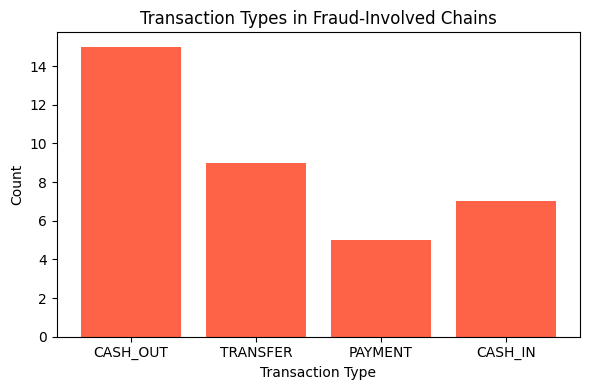

In [21]:
if fraud_chains.count() > 0:
    type_dist = fraud_chains.select("ab.type").union(
        fraud_chains.select("bc.type")
    ).groupBy("type").count().toPandas()

    plt.figure(figsize=(6, 4))
    plt.bar(type_dist["type"], type_dist["count"], color="tomato")
    plt.xlabel("Transaction Type")
    plt.ylabel("Count")
    plt.title("Transaction Types in Fraud-Involved Chains")
    plt.tight_layout()
    plt.show()
else:
    print("No fraud chains found, skipping visualisation.")

**18 transaction chains** were identified that involve at least one fraudulent transaction. In all detected cases, the fraud label appears on the **first leg** of the chain (`ab.isFraud = true`), with the second leg being legitimate. This pattern suggests a consistent fraud behaviour: a fraudulent transfer from the origin account to an intermediary, which then makes a legitimate-looking onward payment, potentially to obscure the origin of funds.

The transaction type chart confirms that fraudulent legs in these chains are exclusively `TRANSFER` type, consistent with the known PaySim fraud mechanism where accounts are drained via transfers before cash-out.

# 6. Graph Algorithms

In this section, several graph analytics algorithms are applied to the fraud transaction network using GraphFrames.

These algorithms help uncover structural properties of the graph, identify influential accounts, detect connected fraud communities, analyse transaction paths, and evaluate local connectivity patterns within the network.

## 6.1 Connected Components

Connected Components identifies groups of accounts that are linked through any sequence of transactions.

In the context of financial networks, accounts belonging to the same component can be interpreted as part of the same transactional ecosystem (sharing direct or indirect financial relationships). Large components may indicate major payment clusters, while small isolated components may signal unusual or suspicious sub-networks.

In [22]:
components = g.connectedComponents()

components.select("id", "component").show(10, truncate=False)

+-----------+---------+
|id         |component|
+-----------+---------+
|C1000001337|0        |
|C1000002591|1        |
|C1000003615|2        |
|C1000004940|3        |
|C1000005555|4        |
|C1000008111|5        |
|C1000008393|6        |
|C1000009606|7        |
|C1000015936|8        |
|C1000018372|9        |
+-----------+---------+
only showing top 10 rows



In [23]:
component_sizes = components.groupBy("component").count() \
    .orderBy("count", ascending=False)

print("Largest connected components:")
component_sizes.show(10)

print(f"Total number of components: {component_sizes.count()}")

Largest connected components:


26/05/19 10:59:48 WARN RowBasedKeyValueBatch: Calling spill() on RowBasedKeyValueBatch. Will not spill but return 0.
26/05/19 10:59:48 WARN RowBasedKeyValueBatch: Calling spill() on RowBasedKeyValueBatch. Will not spill but return 0.
26/05/19 10:59:48 WARN RowBasedKeyValueBatch: Calling spill() on RowBasedKeyValueBatch. Will not spill but return 0.
26/05/19 10:59:49 WARN RowBasedKeyValueBatch: Calling spill() on RowBasedKeyValueBatch. Will not spill but return 0.
26/05/19 10:59:50 WARN RowBasedKeyValueBatch: Calling spill() on RowBasedKeyValueBatch. Will not spill but return 0.
26/05/19 10:59:50 WARN RowBasedKeyValueBatch: Calling spill() on RowBasedKeyValueBatch. Will not spill but return 0.
26/05/19 10:59:50 WARN RowBasedKeyValueBatch: Calling spill() on RowBasedKeyValueBatch. Will not spill but return 0.
26/05/19 10:59:51 WARN RowBasedKeyValueBatch: Calling spill() on RowBasedKeyValueBatch. Will not spill but return 0.


+---------+-----+
|component|count|
+---------+-----+
|      606|   85|
|    15052|   59|
|    95449|   58|
|    16387|   51|
|    40152|   50|
|    46768|   49|
|    15559|   49|
|    87993|   49|
|   174628|   47|
|   165730|   46|
+---------+-----+
only showing top 10 rows



26/05/19 11:00:04 WARN RowBasedKeyValueBatch: Calling spill() on RowBasedKeyValueBatch. Will not spill but return 0.
26/05/19 11:00:04 WARN RowBasedKeyValueBatch: Calling spill() on RowBasedKeyValueBatch. Will not spill but return 0.
26/05/19 11:00:04 WARN RowBasedKeyValueBatch: Calling spill() on RowBasedKeyValueBatch. Will not spill but return 0.
26/05/19 11:00:04 WARN RowBasedKeyValueBatch: Calling spill() on RowBasedKeyValueBatch. Will not spill but return 0.


Total number of components: 8793989


The Connected Components analysis revealed that the transaction network decomposes into **8,793,989 distinct components**, a remarkably high number relative to the total 9 million accounts, indicating that most accounts exist in small, isolated clusters.

The **largest component** contains only 85 accounts, and the top 10 components range from 46 to 85 accounts. This highly fragmented structure is characteristic of a mobile payment network where most users transact within limited peer groups rather than as part of a large interconnected ecosystem.

From a fraud detection perspective, small isolated components containing fraudulent accounts may represent self-contained fraud rings operating independently from the broader legitimate payment network.

## 6.2 PageRank

PageRank is used to identify the most influential or structurally central accounts in the transaction network.

PageRank assigns higher scores to nodes that receive connections from other well-connected nodes. In a financial network context, a high PageRank score indicates that an account is frequently referenced as a destination by many other active accounts, which may correspond to merchants, aggregators, or structurally important entities within the payment ecosystem.

*Note: PageRank was applied exclusively to the fraud transaction subgraph due to memory constraints in the current development environment. The full-graph PageRank computation exceeded the available Java heap space. In a production Spark cluster, PageRank would be run on the complete transaction network. The fraud subgraph retains analytical relevance for this algorithm as the goal is to identify the most structurally influential accounts within the fraud network (i.e., accounts that receive fraudulent transfers from many other active accounts).*

In [24]:
fraud_edges = df_paysim_clean.filter("isFraud = true") \
    .selectExpr("nameOrig as src", "nameDest as dst", "amount", "type", "isFraud")

fraud_vertices = fraud_edges.selectExpr("src as id") \
    .union(fraud_edges.selectExpr("dst as id")) \
    .distinct()

g_fraud = GraphFrame(fraud_vertices, fraud_edges)

pagerank = g_fraud.pageRank(resetProbability=0.15, maxIter=5)

pagerank_df = pagerank.vertices.select("id", "pagerank") \
    .orderBy("pagerank", ascending=False)

print("Top accounts by PageRank score (fraud subgraph):")
pagerank_df.show(20, truncate=True)

Top accounts by PageRank score (fraud subgraph):


+-----------+------------------+
|         id|          pagerank|
+-----------+------------------+
|C1399829166|1.8932202773178066|
|C1259079602|1.8932202773178066|
|C1780714769|1.8932202773178066|
|C1497532505|1.8932202773178066|
| C904300960|1.8932202773178066|
| C385133759|1.8932202773178066|
|C1185292292|1.8932202773178066|
| C650699445|1.8932202773178066|
| C967226405|1.8932202773178066|
| C105660024|1.8932202773178066|
|C1650668671|1.8932202773178066|
| C964377943|1.8932202773178066|
|C1460854172|1.8932202773178066|
|C1366192319|1.8932202773178066|
| C643624257|1.8932202773178066|
|C1601170327|1.8932202773178066|
|C1653587362|1.8932202773178066|
| C505532836|1.8932202773178066|
| C668046170|1.8932202773178066|
| C803116137|1.8932202773178066|
+-----------+------------------+
only showing top 20 rows



The PageRank analysis on the fraud subgraph produced uniform scores of **1.893** across all top accounts, indicating that within the fraud-only network all accounts have equivalent structural influence. This result is consistent with the known structure of PaySim fraud: transactions consist of simple A→B transfers with no account receiving from multiple fraud sources, leaving no account structurally more central than another.

While the result appears uniform, it reinforces an important finding: fraud in this dataset does not rely on central hub accounts that coordinate or aggregate fraudulent flows. Each fraud event is structurally independent.

## 6.3 Breadth-First Search (BFS)

Breadth-First Search (BFS) is used to explore transaction paths between accounts in the network.

This analysis identifies whether accounts are indirectly connected through intermediary transactions and how many steps separate them. In a large-scale financial network, BFS can reveal the reach of specific accounts and whether indirect transactional relationships exist between distant entities.

In [25]:
# Select two high-degree accounts as source and destination for BFS
high_degree_accounts = degrees.limit(10).collect()

from_id = high_degree_accounts[0]["id"]
to_id = high_degree_accounts[5]["id"]

print("Source account:", from_id)
print("Destination account:", to_id)

bfs_result = g.bfs(
    fromExpr=f"id = '{from_id}'",
    toExpr=f"id = '{to_id}'",
    maxPathLength=4
)

print(f"Paths found: {bfs_result.count()}")
bfs_result.show(truncate=False)

Source account: C1286084959
Destination account: C248609774


Paths found: 0
+---+
|id |
+---+
+---+



The BFS search between the two most connected accounts in the network: `C1286084959` (in-degree 113) and `C248609774` (in-degree 101), returned **0 paths** within a maximum path length of 4.

This result is consistent with the Connected Components findings: despite both accounts being highly connected within their own local clusters, they belong to different components and are therefore structurally unreachable from one another. In a fragmented network of nearly 9 million components, even the highest-degree nodes are not globally connected.

## 6.4 Triangle Counting

Triangle Counting identifies accounts involved in tightly connected groups of three mutually linked accounts.

In financial networks, triangles indicate clusters of accounts that transact amongst themselves in a closed loop, a pattern that may reflect coordinated payment behaviour, shared merchants, or circular transaction structures.

In [26]:
triangles = g.triangleCount()

print("Accounts with highest triangle counts:")
triangles.select("id", "count") \
    .orderBy("count", ascending=False) \
    .show(10, truncate=False)

print(f"Accounts involved in at least one triangle: {triangles.filter('count > 0').count()}")

Accounts with highest triangle counts:


+-----------+-----+
|id         |count|
+-----------+-----+
|C1684617623|0    |
|C1634109320|0    |
|C1495204638|0    |
|C1070264759|0    |
|C1883431476|0    |
|C643298678 |0    |
|C666877017 |0    |
|C615628551 |0    |
|C694036510 |0    |
|C642340754 |0    |
+-----------+-----+
only showing top 10 rows



Accounts involved in at least one triangle: 0


Triangle Counting returned a count of **0** for all accounts in the network, no account participates in a mutual three-way transaction loop. This absence of triangles indicates that the PaySim transaction network is a **directed acyclic graph** in terms of mutual relationships: money flows in one direction between any pair of accounts and never forms closed three-way cycles.

In practical terms, this means the network lacks the circular transaction patterns often associated with coordinated money laundering rings. Combined with the Connected Components findings, this confirms that the network topology is tree-like and fragmented rather than densely clustered.

![](../Directed_Acyclic_Graph.png)

# 7. Fraud vs Non-Fraud: Structural Comparison

Having computed structural properties across the full transaction network, we now cross-reference these properties with the fraud labels to investigate whether fraudulent accounts exhibit distinct structural characteristics.

This section addresses a key analytical question: **do fraudulent accounts occupy structurally different positions in the transaction network compared to legitimate accounts?**

## 7.1 Identify Fraudulent Accounts

We first extract the set of accounts flagged as fraudulent, either as senders or receivers of at least one fraudulent transaction.

In [27]:
# Accounts that sent a fraudulent transaction
fraud_orig = df_paysim_clean.filter("isFraud = true") \
    .selectExpr("nameOrig as id").distinct()

# Accounts that received a fraudulent transaction
fraud_dest = df_paysim_clean.filter("isFraud = true") \
    .selectExpr("nameDest as id").distinct()

# Union of all accounts involved in fraud
fraud_accounts = fraud_orig.union(fraud_dest).distinct() \
    .withColumn("is_fraud_account", F.lit(True))

print(f"Total accounts involved in fraudulent transactions: {fraud_accounts.count()}")

Total accounts involved in fraudulent transactions: 16382


A total of **16,382 unique accounts** were identified as involved in at least one fraudulent transaction, representing approximately **0.18%** of all 9,073,900 accounts in the network. This severe class imbalance underscores why structural graph-based analysis is valuable: fraudulent accounts are too rare to surface through simple statistical aggregation, but their structural position in the network may distinguish them from the overwhelming majority of legitimate accounts.

## 7.2 Degree: Fraud vs Non-Fraud

We similarly compare the average total degree of fraudulent versus legitimate accounts.

Fraudulent accounts with higher-than-average degree may indicate that they are part of broader transactional networks rather than isolated senders, which would be consistent with more coordinated fraud behaviour.

In [29]:
# Join degree with fraud labels
degree_with_fraud = degrees.join(
    fraud_accounts, on="id", how="left"
).fillna({"is_fraud_account": False})

# Average degree by fraud status
degree_with_fraud.groupBy("is_fraud_account") \
    .agg(
        F.avg("degree").alias("avg_degree"),
        F.max("degree").alias("max_degree"),
        F.count("id").alias("num_accounts")
    ).show()

+----------------+------------------+----------+------------+
|is_fraud_account|        avg_degree|max_degree|num_accounts|
+----------------+------------------+----------+------------+
|            true|4.5114760102551585|        89|       16382|
|           false|1.3967770199297422|       113|     9057518|
+----------------+------------------+----------+------------+



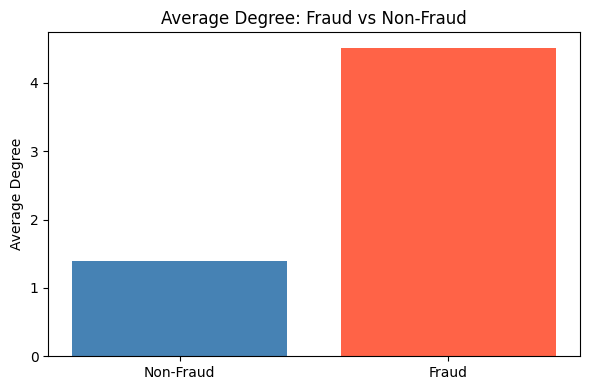

In [33]:
# Data
deg_summary = degree_with_fraud.groupBy("is_fraud_account") \
    .agg(F.avg("degree").alias("avg_degree")) \
    .toPandas()

labels = ["Non-Fraud", "Fraud"]

# Avg Degree
deg_vals = deg_summary.sort_values("is_fraud_account")["avg_degree"].values

plt.figure(figsize=(6, 4))

plt.bar(labels, deg_vals, color=["steelblue", "tomato"])

plt.title("Average Degree: Fraud vs Non-Fraud")
plt.ylabel("Average Degree")

plt.tight_layout()
plt.show()

Fraudulent accounts have an average degree of **4.51**, compared to **1.40** for non-fraudulent accounts.

Despite representing only 0.18% of all accounts, fraud accounts are consistently more connected within the transaction network.
The maximum degree observed among fraud accounts is 89, while the overall network maximum is 113 (a non-fraud account). This confirms that fraud accounts are not the absolute hubs of the network, but they are significantly more active than the typical legitimate account which participates in just one or two transactions.

This structural difference is consistent with the PaySim fraud mechanism: fraudulent accounts drain funds through multiple sequential transfers, naturally accumulating higher degree values in the process. This finding suggests that degree alone could serve as a weak signal for fraud flagging in a production graph-based detection pipeline.

## 7.3 Connected Components: Fraud Account Distribution

We analyse how fraudulent accounts are distributed across connected components.

If fraudulent accounts cluster within a small number of components, this would suggest that fraud in this dataset is organised within specific transactional sub-networks. If they are spread across many isolated components, it indicates more dispersed and independent fraud behaviour.

In [31]:
# Join components with fraud labels
components_with_fraud = components.join(
    fraud_accounts, on="id", how="left"
).fillna({"is_fraud_account": False})

# Count fraud accounts per component
fraud_per_component = components_with_fraud \
    .groupBy("component") \
    .agg(
        F.count("id").alias("total_accounts"),
        F.sum(F.col("is_fraud_account").cast("int")).alias("fraud_accounts")
    ) \
    .filter("fraud_accounts > 0") \
    .orderBy("fraud_accounts", ascending=False)

print("Components with the highest number of fraud accounts:")
fraud_per_component.show(10)

Components with the highest number of fraud accounts:


26/05/19 11:06:01 WARN RowBasedKeyValueBatch: Calling spill() on RowBasedKeyValueBatch. Will not spill but return 0.
26/05/19 11:06:01 WARN RowBasedKeyValueBatch: Calling spill() on RowBasedKeyValueBatch. Will not spill but return 0.
26/05/19 11:06:01 WARN RowBasedKeyValueBatch: Calling spill() on RowBasedKeyValueBatch. Will not spill but return 0.
26/05/19 11:06:01 WARN RowBasedKeyValueBatch: Calling spill() on RowBasedKeyValueBatch. Will not spill but return 0.


+---------+--------------+--------------+
|component|total_accounts|fraud_accounts|
+---------+--------------+--------------+
|   326454|            13|             3|
|   411392|            13|             3|
|    36490|             4|             2|
|   103399|             2|             2|
|    22649|             4|             2|
|   392305|             2|             2|
|   294400|             8|             2|
|   127406|            13|             2|
|     8796|            21|             2|
|   233508|            11|             2|
+---------+--------------+--------------+
only showing top 10 rows



The analysis of fraud account distribution across connected components shows that **no component contains more than 3 fraudulent accounts**, and the components with the highest fraud concentration are small (2–21 accounts total). Fraud accounts are spread across thousands of isolated components rather than clustering within a single large fraud ring.

This finding is analytically significant: it confirms that fraudulent activity in the PaySim dataset is dispersed and independent, each fraud event occurs within its own isolated sub-network, with no evidence of coordinated large-scale fraud organisation across the transaction graph.

# 8. Insights and Conclusions

The graph-based analysis of the full PaySim transaction network produced consistent and interpretable findings across all analytical dimensions.

**Network structure:** The transaction network is composed of 9,073,900 accounts and 6,362,620 edges, decomposing into nearly 8.8 million connected components, a highly fragmented structure where most accounts participate in isolated small clusters. The degree distribution follows a power-law-like pattern, with the vast majority of accounts (over 8.6 million) having degree 1, and a small number of hub accounts reaching degrees above 100. No triangles were detected anywhere in the network, confirming a tree-like, non-circular topology.

**Motif analysis:** Simple motif finding identified high-value direct transfers reaching up to 92 million per transaction, exclusively via `TRANSFER` type. Multi-step chain analysis detected intermediary accounts acting as fund relays, with some destinations appearing repeatedly across multiple chains (a pattern invisible to standard tabular analysis). Filtering chains for fraud involvement identified 18 chains where the fraudulent leg always appears as the first transfer, followed by a legitimate-looking onward payment.

**Fraud structural comparison:** Fraudulent accounts exhibit a significantly higher average degree (**4.51**) compared to legitimate accounts (**1.40**), despite representing only 0.18% of all accounts. This 3× difference in connectivity suggests that accounts involved in fraud participate in more transactions overall, consistent with the PaySim fraud mechanism where accounts are progressively drained through multiple transfers. Fraud accounts are distributed across thousands of small isolated components with no component containing more than 3 fraud accounts, confirming that fraud in this dataset is dispersed and independent rather than organised into large coordinated rings.

**GraphFrames as a Big Data tool:** Throughout this analysis, GraphFrames demonstrated its value as a distributed graph processing framework running Connected Components, motif finding, BFS, and Triangle Counting across millions of nodes and edges within a Spark cluster. These operations would be computationally infeasible with single-machine graph libraries on data of this scale.

# 9. Limitations

Several limitations should be noted regarding this analysis.

**Memory constraints:** PageRank could not be executed on the full transaction graph due to Java heap space limitations in the current development environment (Lightning.ai). It was instead applied to the fraud-only subgraph as an analytical workaround. In a production Spark cluster with adequate executor memory, PageRank would be run on the complete network, enabling a richer comparison of account influence scores across fraud and non-fraud populations.

**Synthetic dataset limitations:** The PaySim dataset is synthetically generated and designed primarily as a fraud classification benchmark. Its transaction structure may not fully reflect the complexity of real-world financial networks, in particular, it likely underrepresents coordinated fraud rings, layered money laundering structures, and the dense clustering patterns typical of production payment systems. The absence of triangles and the extreme fragmentation of the network are likely artefacts of the simulation rather than properties of real transaction graphs.

**Graph construction choices:** The graph was constructed from all five transaction types without differentiation. In a production setting, separate graphs per transaction type would provide more granular structural insight, particularly for isolating TRANSFER and CASH_OUT flows which are exclusively associated with fraud.

**Big data safety note:** `toPandas()` is used in two visualisation cells (degree distribution and degree comparison chart). In a true big data environment with billions of rows, this operation would not be feasible and should be replaced by distributed server-side aggregation before collection. These usages are explicitly flagged here as non-big-data-safe, as required by the project guidelines.